# Task 2 - Invisibility Cloak for Depth Deception

Adapted from Wu et al. arXiv:1910.14667. Universal printable adversarial patch
optimized to push predicted depth in the patched region toward MAX_DEPTH=10m (erase).

Baseline Task 1 (DA-V2-S fine-tune on NYU v2) is frozen and reused via `checkpoints/best_model.pth`.


## 1. Imports

In [ ]:
import os
import io
import csv
import copy
import json
import time
import hashlib
import random
import unittest
from pathlib import Path
from collections import defaultdict
import glob as glob_module
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.utils import save_image
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

In [ ]:
import transformers
print(f'PyTorch:      {torch.__version__}')
print(f'CUDA avail:   {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:          {torch.cuda.get_device_name(0)}')
    print(f'VRAM:         {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB')
print(f'Transformers: {transformers.__version__}')
assert torch.cuda.is_available(), 'CUDA required for attack loop on RTX 4060 Ti.'

PyTorch:      2.6.0+cu124
CUDA avail:   True
GPU:          NVIDIA GeForce RTX 4060 Ti
VRAM:         8.59 GB
Transformers: 5.5.3


## 2. Globals

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_CHECKPOINT = 'depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf'
DATA_ROOT = r'D:\cv\data\nyu_v2'
CHECKPOINT_DIR = r'D:\cv\checkpoints'
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
BASELINE_METRICS_PATH = os.path.join(CHECKPOINT_DIR, 'baseline_metrics.json')
VIZ_DIR = os.path.join(CHECKPOINT_DIR, 'viz_task2')
os.makedirs(VIZ_DIR, exist_ok=True)

INPUT_SIZE = 518
NYU_HEIGHT = 480
NYU_WIDTH  = 640
EVAL_CROP_TOP, EVAL_CROP_BOTTOM = 45, 471
EVAL_CROP_LEFT, EVAL_CROP_RIGHT = 41, 601
MIN_DEPTH = 1e-3
MAX_DEPTH = 10.0

PATCH_SIZE = 128
PATCH_INIT = 'uniform'
PATCH_PATH = os.path.join(CHECKPOINT_DIR, 'adv_patch.pt')
PATCH_PNG  = os.path.join(CHECKPOINT_DIR, 'adv_patch.png')
REPORT_PATH = os.path.join(CHECKPOINT_DIR, 'attack_report.json')
TARGET_DEPTH = MAX_DEPTH
MASK_DILATE_PX = 3
ADV_LOSS_EPS = 1e-3
GRAD_CLIP_PATCH = 1.0
EOT_ROT_DEG    = 15.0
EOT_SCALE_MIN, EOT_SCALE_MAX = 0.7, 1.3
EOT_TRANS_FRAC = 0.20
EOT_BRIGHT     = 0.20
EOT_CONTRAST_MIN, EOT_CONTRAST_MAX = 0.8, 1.2
EOT_NOISE_STD  = 0.02

LAMBDA_ADV = 1.0
LAMBDA_NPS = 5e-3
LAMBDA_TV  = 1e-3

ATTACK_LR    = 1e-2
N_STEPS      = 3000
ATTACK_BATCH = 4
LOG_EVERY    = 25
SAVE_EVERY   = 250
USE_AMP_FORWARD = True
TRAIN_SUBSET_SIZE = 15000
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
PRINTABLE_COLORS = torch.tensor([
    [0.098, 0.082, 0.082], [0.173, 0.102, 0.094], [0.290, 0.118, 0.106],
    [0.392, 0.141, 0.137], [0.510, 0.165, 0.169], [0.627, 0.216, 0.212],
    [0.722, 0.302, 0.286], [0.098, 0.106, 0.204], [0.102, 0.153, 0.345],
    [0.106, 0.196, 0.467], [0.106, 0.243, 0.588], [0.102, 0.298, 0.706],
    [0.122, 0.357, 0.796], [0.235, 0.431, 0.820], [0.102, 0.314, 0.129],
    [0.106, 0.408, 0.165], [0.106, 0.502, 0.200], [0.114, 0.596, 0.243],
    [0.204, 0.694, 0.322], [0.341, 0.769, 0.427], [0.761, 0.694, 0.098],
    [0.827, 0.769, 0.137], [0.878, 0.835, 0.192], [0.914, 0.894, 0.263],
    [0.953, 0.949, 0.380], [0.996, 0.996, 0.996], [0.855, 0.855, 0.855],
    [0.627, 0.627, 0.627], [0.392, 0.392, 0.392], [0.157, 0.157, 0.157],
], dtype=torch.float32)
print(f'DEVICE:       {DEVICE}')
print(f'MODEL:        {MODEL_CHECKPOINT}')
print(f'PATCH_SIZE:   {PATCH_SIZE}x{PATCH_SIZE} -> {PATCH_SIZE*PATCH_SIZE} px, {100*PATCH_SIZE**2/INPUT_SIZE**2:.2f}% of 518^2 frame')
print(f'TARGET_DEPTH: {TARGET_DEPTH} m (push-farther / erase)')
print(f'ATTACK:       bs={ATTACK_BATCH} lr={ATTACK_LR} steps={N_STEPS}')
print(f'PALETTE:      {PRINTABLE_COLORS.shape[0]} printable colors')
print(f'SEED:         {SEED}')

DEVICE:       cuda
MODEL:        depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf
PATCH_SIZE:   128x128 -> 16384 px, 6.11% of 518^2 frame
TARGET_DEPTH: 10.0 m (push-farther / erase)
ATTACK:       bs=4 lr=0.01 steps=3000
PALETTE:      30 printable colors
SEED:         42


In [ ]:
class TestGlobals(unittest.TestCase):
    def test_patch_smaller_than_input(self):
        self.assertLess(PATCH_SIZE, INPUT_SIZE)
    def test_palette_shape_range(self):
        self.assertEqual(PRINTABLE_COLORS.ndim, 2)
        self.assertEqual(PRINTABLE_COLORS.shape[1], 3)
        self.assertGreaterEqual(PRINTABLE_COLORS.min().item(), 0.0)
        self.assertLessEqual(PRINTABLE_COLORS.max().item(), 1.0)
        self.assertGreaterEqual(PRINTABLE_COLORS.shape[0], 20)
    def test_depth_range_sane(self):
        self.assertGreater(MAX_DEPTH, MIN_DEPTH)
        self.assertEqual(TARGET_DEPTH, MAX_DEPTH)
    def test_checkpoint_exists(self):
        self.assertTrue(os.path.exists(BEST_MODEL_PATH), f'missing {BEST_MODEL_PATH}')
        self.assertTrue(os.path.exists(BASELINE_METRICS_PATH), f'missing {BASELINE_METRICS_PATH}')
unittest.main(argv=['_'], module='__main__', exit=False, verbosity=2)

test_checkpoint_exists (__main__.TestGlobals.test_checkpoint_exists) ... 

ok


test_depth_range_sane (__main__.TestGlobals.test_depth_range_sane) ... 

ok


test_palette_shape_range (__main__.TestGlobals.test_palette_shape_range) ... 

ok


test_patch_smaller_than_input (__main__.TestGlobals.test_patch_smaller_than_input) ... 

ok


----------------------------------------------------------------------
Ran 4 tests in 0.003s

OK


## 3. Utils

### 3.1 Reused from Task 1 baseline (verbatim)

In [ ]:
class SILogLoss(nn.Module):
    """Scale-Invariant Logarithmic Loss (Eigen 2014)"""
    def __init__(self, variance_focus: float = 0.5):
        super().__init__()
        self.variance_focus = variance_focus
    def forward(self, pred, gt, valid_mask=None):
        if valid_mask is None:
            valid_mask = (gt > MIN_DEPTH) & (gt < MAX_DEPTH)
        valid_mask = valid_mask.bool()
        pred_v = pred[valid_mask].clamp(min=MIN_DEPTH)
        gt_v   = gt[valid_mask].clamp(min=MIN_DEPTH)
        if pred_v.numel() == 0:
            return torch.tensor(0.0, device=pred.device, requires_grad=True)
        d = torch.log(pred_v) - torch.log(gt_v)
        return torch.sqrt(torch.mean(d ** 2) - self.variance_focus * (torch.mean(d) ** 2) + 1e-12)


In [ ]:
def compute_depth_metrics(pred, gt, min_depth=MIN_DEPTH, max_depth=MAX_DEPTH, eigen_crop: bool = False):
    """8 standard NYU depth metrics. Reused from Task 1."""
    pred = pred.detach().float()
    gt = gt.detach().float()
    if eigen_crop:
        pred = pred[..., EVAL_CROP_TOP:EVAL_CROP_BOTTOM, EVAL_CROP_LEFT:EVAL_CROP_RIGHT]
        gt   = gt[...,   EVAL_CROP_TOP:EVAL_CROP_BOTTOM, EVAL_CROP_LEFT:EVAL_CROP_RIGHT]
    valid = (gt > min_depth) & (gt < max_depth)
    pred_v = pred[valid].clamp(min=min_depth, max=max_depth)
    gt_v = gt[valid]
    if gt_v.numel() == 0:
        return {k: 0.0 for k in ('abs_rel','sq_rel','rmse','rmse_log','log10','delta1','delta2','delta3')}
    abs_diff = (pred_v - gt_v).abs()
    ratio = torch.max(pred_v / gt_v, gt_v / pred_v)
    return {
        'abs_rel':  (abs_diff / gt_v).mean().item(),
        'sq_rel':   ((abs_diff ** 2) / gt_v).mean().item(),
        'rmse':     torch.sqrt((abs_diff ** 2).mean()).item(),
        'rmse_log': torch.sqrt(((torch.log(pred_v) - torch.log(gt_v)) ** 2).mean()).item(),
        'log10':    (torch.log10(pred_v) - torch.log10(gt_v)).abs().mean().item(),
        'delta1':   (ratio < 1.25   ).float().mean().item(),
        'delta2':   (ratio < 1.25**2).float().mean().item(),
        'delta3':   (ratio < 1.25**3).float().mean().item(),
    }

In [ ]:
def load_depth_map(path, max_depth=MAX_DEPTH):
    depth_raw = np.array(Image.open(path))
    if depth_raw.dtype == np.uint8:
        return depth_raw.astype(np.float32) / 255.0 * max_depth
    return depth_raw.astype(np.float32) / 1000.0
def verify_gradient_flow(model, sample_input, device=None):
    device = device or DEVICE
    model.eval()
    x = sample_input.clone().detach().to(device).requires_grad_(True)
    out = model(pixel_values=x)
    pred = out.predicted_depth if hasattr(out, 'predicted_depth') else out[0]
    pred.sum().backward()
    ok = (x.grad is not None) and (not torch.all(x.grad == 0))
    if ok:
        g = x.grad.abs()
        print(f'  input grad: min={g.min():.2e} max={g.max():.2e} mean={g.mean():.2e}')
    else:
        print('  WARNING: no gradient flow to input!')
    model.zero_grad()
    return ok

In [ ]:
def discover_nyu_pairs(data_root):
    """NYU v2 Kaggle soumikrakshit layout discovery"""
    data_root = str(data_root)
    csv_files = sorted(glob_module.glob(os.path.join(data_root, '**', '*.csv'), recursive=True))
    if csv_files:
        train_pairs, test_pairs = [], []
        for csv_path in csv_files:
            csv_dir = os.path.dirname(csv_path)
            with open(csv_path, 'r') as f:
                rows = list(csv.reader(f))
            pairs = []
            for row in rows:
                if len(row) < 2: continue
                rgb_rel = row[0].strip().lstrip('/')
                dep_rel = row[1].strip().lstrip('/')
                for base in (csv_dir, data_root, os.path.dirname(csv_dir)):
                    rp = os.path.join(base, rgb_rel); dp = os.path.join(base, dep_rel)
                    if os.path.exists(rp) and os.path.exists(dp):
                        pairs.append((rp, dp)); break
                    parts_r = rgb_rel.split('/', 1); parts_d = dep_rel.split('/', 1)
                    if len(parts_r) > 1:
                        rp2 = os.path.join(base, parts_r[1]); dp2 = os.path.join(base, parts_d[1])
                        if os.path.exists(rp2) and os.path.exists(dp2):
                            pairs.append((rp2, dp2)); break
            name = os.path.basename(csv_path).lower()
            (test_pairs if 'test' in name else train_pairs).__iadd__([])
            if 'test' in name:
                test_pairs = pairs
            else:
                train_pairs = pairs
            print(f'  {os.path.basename(csv_path)}: {len(rows)} rows -> {len(pairs)} resolved pairs')
        if train_pairs:
            return train_pairs, test_pairs
    raise RuntimeError(f'No NYU pairs discovered in {data_root}.')


In [ ]:
class NYUDepthDataset(Dataset):
    def __init__(self, rgb_paths, depth_paths, processor, input_size=INPUT_SIZE,
                 augment=False, keep_original=False):
        assert len(rgb_paths) == len(depth_paths)
        self.rgb_paths = rgb_paths
        self.depth_paths = depth_paths
        self.processor = processor
        self.input_size = input_size
        self.augment = augment
        self.keep_original = keep_original
    def __len__(self):
        return len(self.rgb_paths)
    def __getitem__(self, idx):
        image = Image.open(self.rgb_paths[idx]).convert('RGB')
        depth_np = load_depth_map(self.depth_paths[idx])
        if self.augment and random.random() > 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)
            depth_np = np.fliplr(depth_np).copy()
        image_square = image.resize((self.input_size, self.input_size), Image.BICUBIC)
        inputs = self.processor(images=image_square, return_tensors='pt',
                                do_resize=False, do_rescale=True, do_normalize=True)
        pixel_values = inputs['pixel_values'].squeeze(0)
        d_t = torch.from_numpy(depth_np).unsqueeze(0).unsqueeze(0).float()
        d_resized = F.interpolate(d_t, size=(self.input_size, self.input_size),
                                  mode='nearest').squeeze(0)
        valid_mask = (d_resized > MIN_DEPTH) & (d_resized < MAX_DEPTH)
        out = {'pixel_values': pixel_values, 'depth_gt': d_resized, 'valid_mask': valid_mask}
        if self.keep_original:
            out['depth_original'] = torch.from_numpy(depth_np).unsqueeze(0).float()
            img_canon = image.resize((NYU_WIDTH, NYU_HEIGHT), Image.BICUBIC)
            out['rgb_original'] = torch.from_numpy(np.array(img_canon)).permute(2, 0, 1)
        return out


In [ ]:
@torch.no_grad()
def validate(model, loader, loss_fn, device, eigen_crop=True):
    model.eval()
    total_loss = 0.0
    agg = defaultdict(float)
    n = 0
    for batch in tqdm(loader, desc='Val', leave=False):
        pv = batch['pixel_values'].to(device, non_blocking=True)
        gt_orig = batch['depth_original'].to(device, non_blocking=True)
        out = model(pixel_values=pv)
        pred = out.predicted_depth.unsqueeze(1)
        pred_480 = F.interpolate(pred, size=(NYU_HEIGHT, NYU_WIDTH),
                                 mode='bilinear', align_corners=False).squeeze(1)
        gt_480 = gt_orig.squeeze(1)
        gt_at_in = F.interpolate(gt_orig, size=pred.shape[-2:], mode='nearest').squeeze(1)
        vm_at_in = (gt_at_in > MIN_DEPTH) & (gt_at_in < MAX_DEPTH)
        loss = loss_fn(out.predicted_depth, gt_at_in, vm_at_in)
        if torch.isfinite(loss):
            total_loss += loss.item()
        m = compute_depth_metrics(pred_480, gt_480, eigen_crop=eigen_crop)
        for k, v in m.items():
            agg[k] += v
        n += 1
    return (total_loss / max(n, 1)), {k: v / max(n, 1) for k, v in agg.items()}

### 3.2 New utils for Task 2

In [ ]:
_IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
_IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
def imagenet_normalize(x: torch.Tensor) -> torch.Tensor:
    m = _IMAGENET_MEAN.to(x.device, x.dtype)
    s = _IMAGENET_STD.to(x.device, x.dtype)
    return (x - m) / s
def imagenet_denormalize(x: torch.Tensor) -> torch.Tensor:
    m = _IMAGENET_MEAN.to(x.device, x.dtype)
    s = _IMAGENET_STD.to(x.device, x.dtype)
    return x * s + m

In [ ]:
def tv_loss(patch: torch.Tensor) -> torch.Tensor:
    dh = (patch[..., 1:, :] - patch[..., :-1, :]).abs().mean()
    dw = (patch[..., :, 1:] - patch[..., :, :-1]).abs().mean()
    return dh + dw
_p_const = torch.full((3, PATCH_SIZE, PATCH_SIZE), 0.5)
_p_check = torch.zeros(3, PATCH_SIZE, PATCH_SIZE)
_p_check[:, ::2, ::2] = 1.0; _p_check[:, 1::2, 1::2] = 1.0
assert tv_loss(_p_const).item() < 1e-6, 'T3a: tv_loss on constant must be ~0'
assert tv_loss(_p_check).item() > 0.5, 'T3b: tv_loss on checkerboard must be > 0.5'
print(f'T3 PASS: tv_const={tv_loss(_p_const).item():.2e}  tv_check={tv_loss(_p_check).item():.4f}')


T3 PASS: tv_const=0.00e+00  tv_check=2.0000


In [ ]:
def nps_loss(patch: torch.Tensor, palette: torch.Tensor) -> torch.Tensor:
    p = patch.permute(1, 2, 0).reshape(-1, 3)
    pal = palette.to(p.device, p.dtype)
    d = torch.cdist(p.unsqueeze(0), pal.unsqueeze(0)).squeeze(0)
    return d.min(dim=1).values.mean()
_pal = PRINTABLE_COLORS
_c = _pal[0]
_p_mono = _c.view(3, 1, 1).expand(3, PATCH_SIZE, PATCH_SIZE).contiguous()
_p_rand = torch.rand(3, PATCH_SIZE, PATCH_SIZE)
assert nps_loss(_p_mono, _pal).item() < 1e-5, 'T2a: nps on pure palette color must be ~0'
assert nps_loss(_p_rand, _pal).item() > 0.0, 'T2b: nps on random patch must be > 0'
print(f'T2 PASS: nps_mono={nps_loss(_p_mono,_pal).item():.2e}  nps_rand={nps_loss(_p_rand,_pal).item():.4f}')


T2 PASS: nps_mono=0.00e+00  nps_rand=0.2377


In [ ]:
def sample_eot_params(batch_size: int, device: torch.device) -> dict:
    d = device
    return {
        'theta_deg':  (torch.rand(batch_size, device=d) * 2 - 1) * EOT_ROT_DEG,
        'scale':       torch.rand(batch_size, device=d) * (EOT_SCALE_MAX - EOT_SCALE_MIN) + EOT_SCALE_MIN,
        'tx':         (torch.rand(batch_size, device=d) * 2 - 1) * EOT_TRANS_FRAC,
        'ty':         (torch.rand(batch_size, device=d) * 2 - 1) * EOT_TRANS_FRAC,
        'brightness': (torch.rand(batch_size, device=d) * 2 - 1) * EOT_BRIGHT,
        'contrast':    torch.rand(batch_size, device=d) * (EOT_CONTRAST_MAX - EOT_CONTRAST_MIN) + EOT_CONTRAST_MIN,
        'noise_std':  torch.tensor(EOT_NOISE_STD, device=d),
    }
def identity_eot(batch_size: int, device: torch.device) -> dict:
    d = device
    z = torch.zeros(batch_size, device=d)
    return {
        'theta_deg': z, 'scale': torch.ones(batch_size, device=d),
        'tx': z.clone(), 'ty': z.clone(),
        'brightness': z.clone(), 'contrast': torch.ones(batch_size, device=d),
        'noise_std': torch.tensor(0.0, device=d),
    }

In [ ]:
def build_affine_theta(scale: torch.Tensor, theta_deg: torch.Tensor,
                       tx: torch.Tensor, ty: torch.Tensor,
                       patch_hw: int, image_hw: int) -> torch.Tensor:
    B = scale.shape[0]
    theta_rad = theta_deg * (torch.pi / 180.0)
    cos = torch.cos(-theta_rad)
    sin = torch.sin(-theta_rad)
    inv_s = 1.0 / scale
    a11 =  inv_s * cos
    a12 = -inv_s * sin
    a21 =  inv_s * sin
    a22 =  inv_s * cos
    tx_in = -(a11 * tx + a12 * ty)
    ty_in = -(a21 * tx + a22 * ty)
    theta = torch.stack([
        torch.stack([a11, a12, tx_in], dim=-1),
        torch.stack([a21, a22, ty_in], dim=-1),
    ], dim=-2)
    return theta
def _pad_patch_to_image(patch: torch.Tensor, image_hw: int, batch_size: int) -> torch.Tensor:
    C, P, _ = patch.shape
    pad_total = image_hw - P
    assert pad_total >= 0, f'patch P={P} must be <= image_hw={image_hw}'
    pl = pad_total // 2
    pr = pad_total - pl

    padded = F.pad(patch, (pl, pr, pl, pr), mode='constant', value=0.0)
    return padded.unsqueeze(0).expand(batch_size, -1, -1, -1)
def differentiable_affine_composite(image: torch.Tensor,
                                    patch: torch.Tensor,
                                    eot: dict) -> tuple:
    B, _, H, W = image.shape
    assert H == W, 'current implementation assumes square image canvas'
    alpha = torch.ones(1, patch.shape[1], patch.shape[2], device=patch.device, dtype=patch.dtype)
    rgba = torch.cat([patch, alpha], dim=0)
    canvas = _pad_patch_to_image(rgba, H, B)
    theta = build_affine_theta(eot['scale'], eot['theta_deg'], eot['tx'], eot['ty'],
                               patch_hw=patch.shape[1], image_hw=H).to(image.device, image.dtype)
    grid = F.affine_grid(theta, size=[B, 4, H, W], align_corners=False)
    warped = F.grid_sample(canvas, grid, mode='bilinear',
                           padding_mode='zeros', align_corners=False)
    rgb = warped[:, :3]
    a   = warped[:, 3:4]
    comp = a * rgb + (1.0 - a) * image
    mask = (a > 0.5).float()
    return comp, mask
def dilate_mask(mask: torch.Tensor, px: int) -> torch.Tensor:
    if px <= 0:
        return mask
    k = 2 * px + 1
    return F.max_pool2d(mask, kernel_size=k, stride=1, padding=px)

In [ ]:
_B = 2
_img = torch.zeros(_B, 3, INPUT_SIZE, INPUT_SIZE)
_patch = torch.full((3, PATCH_SIZE, PATCH_SIZE), 0.7)
_patch.requires_grad_(True)
_eot = identity_eot(_B, torch.device('cpu'))
_comp, _mask = differentiable_affine_composite(_img, _patch, _eot)
_pl = (INPUT_SIZE - PATCH_SIZE) // 2
_naive = torch.zeros(_B, 3, INPUT_SIZE, INPUT_SIZE)
_naive[:, :, _pl:_pl+PATCH_SIZE, _pl:_pl+PATCH_SIZE] = 0.7
_naive_mask = torch.zeros(_B, 1, INPUT_SIZE, INPUT_SIZE)
_naive_mask[:, :, _pl:_pl+PATCH_SIZE, _pl:_pl+PATCH_SIZE] = 1.0
_iou = (_mask * _naive_mask).sum() / ((_mask + _naive_mask).clamp_max(1.0).sum() + 1e-8)
print(f'T1 identity:  L1(comp-naive)={(_comp - _naive).abs().mean().item():.2e}  mask_IoU={_iou.item():.4f}')
assert (_comp - _naive).abs().mean().item() < 1e-5, 'T1a: identity composite must match naive paste'
assert _iou.item() > 0.98, 'T1b: identity mask IoU must be > 0.98'
_comp.sum().backward()
assert _patch.grad is not None and _patch.grad.abs().max() > 0, 'T1c: patch grad must flow'
print(f'T1c grad: max|grad|={_patch.grad.abs().max().item():.4f}')
_eot90 = identity_eot(_B, torch.device('cpu'))
_eot90['theta_deg'] = torch.full((_B,), 90.0)
_patch2 = torch.zeros(3, PATCH_SIZE, PATCH_SIZE)
_patch2[:, :PATCH_SIZE//2, :] = 1.0
_, _mask90 = differentiable_affine_composite(_img, _patch2, _eot90)
_area_ratio = _mask90.sum().item() / _naive_mask.sum().item()
print(f'T1d rot90 mask area ratio: {_area_ratio:.4f}')
assert 0.90 < _area_ratio < 1.10, 'T1d: rotated mask area should be ~preserved'
print('T1 PASS')

T1 identity:  L1(comp-naive)=1.39e-10  mask_IoU=1.0000
T1c grad: max|grad|=2.0001
T1d rot90 mask area ratio: 1.0000
T1 PASS


In [ ]:
def apply_color_jitter(images: torch.Tensor, brightness: torch.Tensor, contrast: torch.Tensor) -> torch.Tensor:
    b = brightness.view(-1, 1, 1, 1).to(images.dtype)
    c = contrast.view(-1, 1, 1, 1).to(images.dtype)
    out = (images - 0.5) * c + 0.5 + b
    return out.clamp(0.0, 1.0)
def adv_depth_loss(pred_depth: torch.Tensor, mask: torch.Tensor,
                   target: float = MAX_DEPTH, eps: float = ADV_LOSS_EPS) -> torch.Tensor:
    if mask.dim() == 4:
        mask = mask.squeeze(1)
    m = mask.float()
    arg = (target - pred_depth + eps).clamp_min(eps)
    return (torch.log(arg) * m).sum() / m.sum().clamp_min(1.0)
def render_patch_png(patch: torch.Tensor, path: str) -> None:
    save_image(patch.detach().cpu().clamp(0, 1), path)
import math as _math_t4
_pred = torch.full((2, INPUT_SIZE, INPUT_SIZE), TARGET_DEPTH)
_mask = torch.zeros(2, 1, INPUT_SIZE, INPUT_SIZE)
_mask[:, :, 100:200, 100:200] = 1.0
_l_min = adv_depth_loss(_pred, _mask, TARGET_DEPTH).item()
assert abs(_l_min - _math_t4.log(ADV_LOSS_EPS)) < 1e-3, f'T4a: pred=target should give log(eps)={_math_t4.log(ADV_LOSS_EPS):.3f}, got {_l_min}'
_pred0 = torch.zeros(2, INPUT_SIZE, INPUT_SIZE)
_l_max = adv_depth_loss(_pred0, _mask, TARGET_DEPTH).item()
assert abs(_l_max - _math_t4.log(TARGET_DEPTH + ADV_LOSS_EPS)) < 1e-3, f'T4b: pred=0 should give log(target+eps), got {_l_max}'

_pred_mid = torch.full((2, INPUT_SIZE, INPUT_SIZE), 5.0)
_l_mid = adv_depth_loss(_pred_mid, _mask, TARGET_DEPTH).item()
assert _l_max > _l_mid > _l_min, 'T4c: loss must be monotone decreasing in pred'
print(f'T4 PASS: L(pred=0)={_l_max:.3f}  L(pred=5)={_l_mid:.3f}  L(pred=target)={_l_min:.3f}')


T4 PASS: L(pred=0)=2.303  L(pred=5)=1.610  L(pred=target)=-6.908


In [18]:
def load_baseline_model(ckpt_path: str, device: torch.device) -> nn.Module:
    """Build HF DA-V2-S, load Task 1 checkpoint strict=True, freeze all params, eval mode."""
    model = AutoModelForDepthEstimation.from_pretrained(MODEL_CHECKPOINT).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    missing, unexpected = model.load_state_dict(ckpt['model_state_dict'], strict=True)
    assert len(missing) == 0 and len(unexpected) == 0, f'strict load failed: {missing} {unexpected}'
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    print(f'Loaded baseline from {ckpt_path}')
    print(f'  ckpt epoch: {ckpt.get("epoch")}')
    print(f'  ckpt metrics: {ckpt.get("metrics")}')
    return model


## 4. Data

In [ ]:
image_processor = AutoImageProcessor.from_pretrained(MODEL_CHECKPOINT)
print(f'Processor: {type(image_processor).__name__}')
print(f'  mean={image_processor.image_mean}  std={image_processor.image_std}')

Processor: DPTImageProcessor
  mean=(0.485, 0.456, 0.406)  std=(0.229, 0.224, 0.225)


In [ ]:
train_pairs, test_pairs = discover_nyu_pairs(DATA_ROOT)
print(f'Train pairs: {len(train_pairs)}  |  Test pairs: {len(test_pairs)}')
random.seed(SEED)
if TRAIN_SUBSET_SIZE is not None and len(train_pairs) > TRAIN_SUBSET_SIZE:
    train_sub = random.sample(train_pairs, TRAIN_SUBSET_SIZE)
    print(f'Subsampled train: {len(train_pairs)} -> {len(train_sub)} pairs')
else:
    train_sub = train_pairs
train_rgb = [p[0] for p in train_sub]
train_dep = [p[1] for p in train_sub]
test_rgb  = [p[0] for p in test_pairs]
test_dep  = [p[1] for p in test_pairs]
attack_train_ds = NYUDepthDataset(train_rgb, train_dep, image_processor, augment=False, keep_original=True)
eval_test_ds    = NYUDepthDataset(test_rgb,  test_dep,  image_processor, augment=False, keep_original=True)
attack_train_loader = DataLoader(attack_train_ds, batch_size=ATTACK_BATCH, shuffle=True,
                                  num_workers=0, pin_memory=True, drop_last=True)
eval_test_loader    = DataLoader(eval_test_ds,    batch_size=4,           shuffle=False,
                                  num_workers=0, pin_memory=True)
print(f'Attack train: {len(attack_train_ds)} samples -> {len(attack_train_loader)} batches (bs={ATTACK_BATCH})')
print(f'Eval test:    {len(eval_test_ds)} samples')
_b = next(iter(attack_train_loader))
print('Batch shapes:')
for k, v in _b.items():
    print(f'  {k}: {tuple(v.shape)} {v.dtype}')

  nyu2_test.csv: 654 rows -> 654 resolved pairs


  nyu2_train.csv: 50688 rows -> 50688 resolved pairs
Train pairs: 50688  |  Test pairs: 654
Subsampled train: 50688 -> 15000 pairs
Attack train: 15000 samples -> 3750 batches (bs=4)
Eval test:    654 samples
Batch shapes:
  pixel_values: (4, 3, 518, 518) torch.float32
  depth_gt: (4, 1, 518, 518) torch.float32
  valid_mask: (4, 1, 518, 518) torch.bool
  depth_original: (4, 1, 480, 640) torch.float32
  rgb_original: (4, 3, 480, 640) torch.uint8


## 5. Network

In [ ]:
model = load_baseline_model(BEST_MODEL_PATH, DEVICE)
gr_ok = verify_gradient_flow(model, torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE))
assert gr_ok, 'Frozen model must still allow gradient flow to input pixels.'

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Loaded baseline from D:\cv\checkpoints\best_model.pth
  ckpt epoch: 2
  ckpt metrics: {'abs_rel': 0.08969896945466356, 'sq_rel': 0.0432304761361149, 'rmse': 0.34927842911423707, 'rmse_log': 0.12098649950561727, 'log10': 0.03779537297739852, 'delta1': 0.9350847332942777, 'delta2': 0.9896846119223571, 'delta3': 0.9977638990413852}


  input grad: min=6.76e-06 max=1.19e+02 mean=3.18e+00


In [22]:
if PATCH_INIT == 'uniform':
    patch = torch.empty(3, PATCH_SIZE, PATCH_SIZE, device=DEVICE).uniform_(0, 1)
elif PATCH_INIT == 'gray':
    patch = torch.full((3, PATCH_SIZE, PATCH_SIZE), 0.5, device=DEVICE)
else:
    raise ValueError(PATCH_INIT)
patch.requires_grad_(True)
attack_optim = torch.optim.Adam([patch], lr=ATTACK_LR)
print(f'Patch: {tuple(patch.shape)}  range [{patch.min().item():.3f}, {patch.max().item():.3f}]')
print(f'Optimizer: Adam(lr={ATTACK_LR}) over 1 parameter ({patch.numel()} elements)')


Patch: (3, 128, 128)  range [0.000, 1.000]
Optimizer: Adam(lr=0.01) over 1 parameter (49152 elements)


In [ ]:
_b = next(iter(attack_train_loader))
_rgb = _b['rgb_original'].to(DEVICE).float() / 255.0
_rgb = F.interpolate(_rgb, size=(INPUT_SIZE, INPUT_SIZE), mode='bicubic', align_corners=False).clamp_(0, 1)
_eot = sample_eot_params(_rgb.size(0), DEVICE)
_patch_c = patch.clamp(0, 1)
_comp, _mask = differentiable_affine_composite(_rgb, _patch_c, _eot)
_comp = apply_color_jitter(_comp, _eot['brightness'], _eot['contrast'])
_x = imagenet_normalize(_comp)
with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP_FORWARD):
    _pred = model(pixel_values=_x).predicted_depth
_pred = _pred.float()
_mask_eff = dilate_mask(_mask, MASK_DILATE_PX)
_L = LAMBDA_ADV * adv_depth_loss(_pred, _mask_eff, TARGET_DEPTH) \
   + LAMBDA_NPS * nps_loss(_patch_c, PRINTABLE_COLORS.to(DEVICE)) \
   + LAMBDA_TV  * tv_loss(_patch_c)
attack_optim.zero_grad(set_to_none=True)
_L.backward()
_g = patch.grad
print(f'T5: L={_L.item():.4f}  |grad|_max={_g.abs().max().item():.4e}  |grad|_mean={_g.abs().mean().item():.4e}')
assert _g is not None and torch.isfinite(_g).all(), 'T5: grad must be finite'
assert _g.abs().max().item() > 1e-8, 'T5: grad must be non-trivial'
assert _g.abs().max().item() < 1e3, 'T5: grad exploded'
print('T5 PASS')
attack_optim.zero_grad(set_to_none=True)

T5: L=2.0308  |grad|_max=2.5598e-03  |grad|_mean=1.0364e-04
T5 PASS


### T6: Single-image overfit gate (200 steps, no EoT)

In [ ]:
torch.manual_seed(SEED)
_patch_t6 = torch.empty(3, PATCH_SIZE, PATCH_SIZE, device=DEVICE).uniform_(0, 1).requires_grad_(True)
_opt_t6 = torch.optim.Adam([_patch_t6], lr=ATTACK_LR)
_b = next(iter(attack_train_loader))
_rgb_single = (_b['rgb_original'][:1].to(DEVICE).float() / 255.0)
_rgb_single = F.interpolate(_rgb_single, size=(INPUT_SIZE, INPUT_SIZE),
                             mode='bicubic', align_corners=False).clamp_(0, 1)
_L0, _mean0 = None, None
for _step in range(200):
    _eot_id = identity_eot(1, DEVICE)
    _pc = _patch_t6.clamp(0, 1)
    _comp, _mask = differentiable_affine_composite(_rgb_single, _pc, _eot_id)
    _x = imagenet_normalize(_comp)
    with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP_FORWARD):
        _pred = model(pixel_values=_x).predicted_depth
    _pred = _pred.float()
    _mask_eff = dilate_mask(_mask, MASK_DILATE_PX)
    _L = adv_depth_loss(_pred, _mask_eff, TARGET_DEPTH)
    _mean_now = ((_pred * _mask.squeeze(1)).sum() / _mask.sum().clamp_min(1)).item()
    if _step == 0:
        _L0, _mean0 = _L.item(), _mean_now
    _opt_t6.zero_grad(set_to_none=True)
    _L.backward()
    torch.nn.utils.clip_grad_norm_([_patch_t6], max_norm=GRAD_CLIP_PATCH)
    _opt_t6.step()
    with torch.no_grad():
        _patch_t6.clamp_(0, 1)
    if _step % 25 == 0 or _step == 199:
        print(f'  step {_step:3d}  L_adv={_L.item():.4f}  mean_pred_in_mask={_mean_now:.3f} m')
_L1 = _L.item()
_mean1 = _mean_now
print(f'T6: L_adv {_L0:.4f} -> {_L1:.4f} (delta {_L0-_L1:+.3f} log-units)')
print(f'T6: mean_pred_in_mask {_mean0:.3f} -> {_mean1:.3f} m (delta {_mean1-_mean0:+.3f} m)')
assert _L0 - _L1 >= 4.0, f'T6 FAIL: L_adv dropped only {_L0-_L1:.3f} log-units, need >=4.0'
assert _mean1 - _mean0 >= 5.0, f'T6 FAIL: mean_pred rose only {_mean1-_mean0:+.3f}m, need +5m'
print('T6 PASS (gate open)')
del _patch_t6, _opt_t6
torch.cuda.empty_cache()

  step   0  L_adv=1.8663  mean_pred_in_mask=3.525 m


  step  25  L_adv=1.4463  mean_pred_in_mask=5.801 m


  step  50  L_adv=-2.0501  mean_pred_in_mask=9.116 m


  step  75  L_adv=-5.7875  mean_pred_in_mask=10.596 m


  step 100  L_adv=-6.5338  mean_pred_in_mask=10.780 m


  step 125  L_adv=-6.9069  mean_pred_in_mask=10.734 m


  step 150  L_adv=-6.9078  mean_pred_in_mask=10.956 m


  step 175  L_adv=-6.9078  mean_pred_in_mask=10.956 m


  step 199  L_adv=-6.9078  mean_pred_in_mask=10.957 m
T6: L_adv 1.8663 -> -6.9078 (delta +8.774 log-units)
T6: mean_pred_in_mask 3.525 -> 10.957 m (delta +7.432 m)
T6 PASS (gate open)


## 6. Train (attack loop)

In [ ]:
def attack_step(patch, batch, model, eot_on=True):
    rgb = batch['rgb_original'].to(DEVICE).float() / 255.0
    rgb = F.interpolate(rgb, size=(INPUT_SIZE, INPUT_SIZE),
                        mode='bicubic', align_corners=False).clamp_(0, 1)
    B = rgb.size(0)
    eot = sample_eot_params(B, DEVICE) if eot_on else identity_eot(B, DEVICE)
    patch_c = patch.clamp(0, 1)
    comp, mask = differentiable_affine_composite(rgb, patch_c, eot)
    if eot_on:
        comp = apply_color_jitter(comp, eot['brightness'], eot['contrast'])
        comp = (comp + eot['noise_std'] * torch.randn_like(comp)).clamp_(0, 1)
    x = imagenet_normalize(comp)
    with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=USE_AMP_FORWARD):
        pred = model(pixel_values=x).predicted_depth
    pred = pred.float()
    mask_eff = dilate_mask(mask, MASK_DILATE_PX)
    L_adv = adv_depth_loss(pred, mask_eff, TARGET_DEPTH)
    L_nps = nps_loss(patch_c, PRINTABLE_COLORS.to(DEVICE))
    L_tv  = tv_loss(patch_c)
    L = LAMBDA_ADV * L_adv + LAMBDA_NPS * L_nps + LAMBDA_TV * L_tv
    meta = {
        'L_adv': L_adv.item(), 'L_nps': L_nps.item(), 'L_tv': L_tv.item(),
        'mean_pred_in_mask': ((pred * mask.squeeze(1)).sum() / mask.sum().clamp_min(1)).item(),
    }
    return L, meta


In [ ]:
SKIP_IF_EXISTS = True
if SKIP_IF_EXISTS and os.path.exists(PATCH_PATH):
    print(f'Existing patch found at {PATCH_PATH} -- loading and skipping training.')
    _loaded = torch.load(PATCH_PATH, map_location=DEVICE, weights_only=True)
    with torch.no_grad():
        patch = _loaded.detach().clone().to(DEVICE)
    patch.requires_grad_(True)
    attack_optim = torch.optim.Adam([patch], lr=ATTACK_LR)
    attack_log = []
    _SKIP = True
else:
    _SKIP = False
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
if not _SKIP:
    patch = torch.empty(3, PATCH_SIZE, PATCH_SIZE, device=DEVICE).uniform_(0, 1).requires_grad_(True)
    attack_optim = torch.optim.Adam([patch], lr=ATTACK_LR)
iter_loader = iter(attack_train_loader)
attack_log = []
t_start = time.time()
print(f'Attack start: N_STEPS={N_STEPS} bs={ATTACK_BATCH} lr={ATTACK_LR}')
print('=' * 74)
for step in (range(N_STEPS) if not _SKIP else range(0)):
    try:
        batch = next(iter_loader)
    except StopIteration:
        iter_loader = iter(attack_train_loader)
        batch = next(iter_loader)
    L, meta = attack_step(patch, batch, model, eot_on=True)
    attack_optim.zero_grad(set_to_none=True)
    L.backward()
    torch.nn.utils.clip_grad_norm_([patch], max_norm=GRAD_CLIP_PATCH)
    attack_optim.step()
    with torch.no_grad():
        patch.clamp_(0, 1)
    attack_log.append({'step': step, 'L': L.item(), **meta})
    if step % LOG_EVERY == 0:
        elapsed = time.time() - t_start
        eta = elapsed / max(step+1, 1) * (N_STEPS - step - 1)
        print(f'[{step:5d}/{N_STEPS}] L={L.item():.4f}  L_adv={meta["L_adv"]:.4f}  L_nps={meta["L_nps"]:.4f}  '
              f'L_tv={meta["L_tv"]:.4f}  mean_pred={meta["mean_pred_in_mask"]:.2f}m  '
              f'elapsed={elapsed/60:.1f}m  ETA={eta/60:.1f}m')
    if step % SAVE_EVERY == 0 or step == N_STEPS - 1:
        torch.save(patch.detach().cpu(), PATCH_PATH)
        render_patch_png(patch, PATCH_PNG)
print('=' * 74)
if not _SKIP:
    print(f'Attack done. Wall-clock: {(time.time()-t_start)/60:.1f}m')
    print(f'Saved: {PATCH_PATH}')
    print(f'Saved: {PATCH_PNG}')
else:
    print('Training skipped (used cached patch).')


Attack start: N_STEPS=3000 bs=4 lr=0.01


[    0/3000] L=1.7725  L_adv=1.7707  L_nps=0.2383  L_tv=0.6644  mean_pred=3.80m  elapsed=0.0m  ETA=12.9m


[   25/3000] L=2.0079  L_adv=2.0061  L_nps=0.2408  L_tv=0.6538  mean_pred=2.47m  elapsed=0.1m  ETA=10.6m


[   50/3000] L=1.5834  L_adv=1.5816  L_nps=0.2409  L_tv=0.6425  mean_pred=4.48m  elapsed=0.2m  ETA=10.8m


[   75/3000] L=1.7525  L_adv=1.7506  L_nps=0.2395  L_tv=0.6305  mean_pred=4.20m  elapsed=0.3m  ETA=10.9m


...

[ 2900/3000] L=-0.5697  L_adv=-0.5710  L_nps=0.1847  L_tv=0.3893  mean_pred=8.32m  elapsed=10.8m  ETA=0.4m


[ 2925/3000] L=-1.3932  L_adv=-1.3945  L_nps=0.1849  L_tv=0.3883  mean_pred=8.31m  elapsed=10.9m  ETA=0.3m


[ 2950/3000] L=-1.0300  L_adv=-1.0313  L_nps=0.1845  L_tv=0.3894  mean_pred=7.89m  elapsed=11.0m  ETA=0.2m


[ 2975/3000] L=-0.5105  L_adv=-0.5118  L_nps=0.1845  L_tv=0.3888  mean_pred=7.81m  elapsed=11.1m  ETA=0.1m


Attack done. Wall-clock: 11.2m
Saved: D:\cv\checkpoints\adv_patch.pt
Saved: D:\cv\checkpoints\adv_patch.png


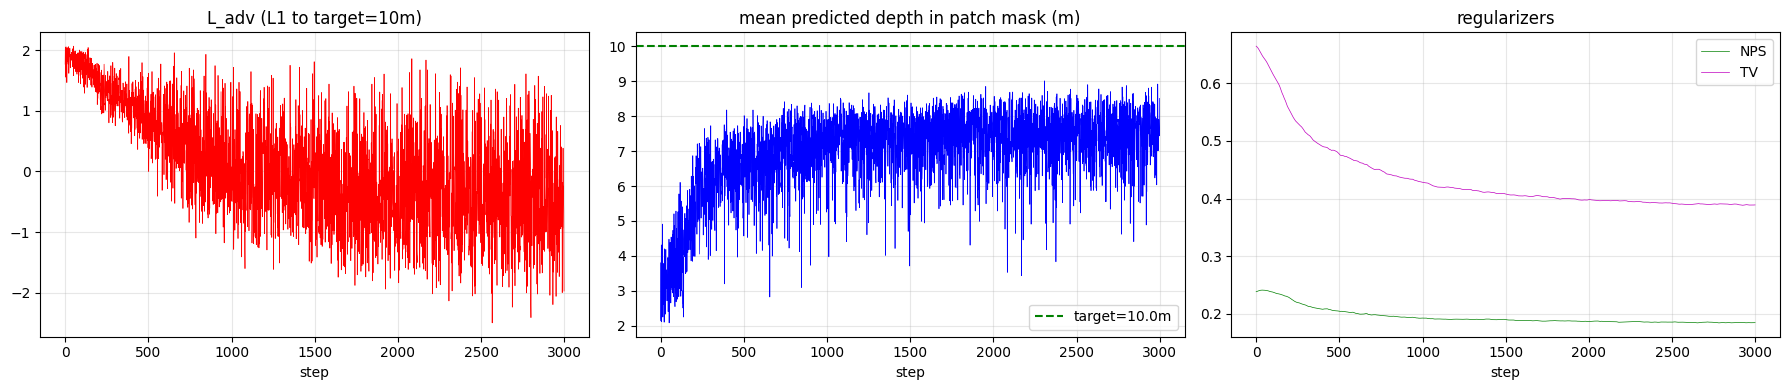

In [ ]:
if len(attack_log) == 0:
    print('No training log (cached patch used). Skipping curves.')
else:
    _steps = [r['step'] for r in attack_log]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(_steps, [r['L_adv'] for r in attack_log], 'r-', linewidth=0.5); axes[0].set_title('L_adv (L1 to target=10m)')
    axes[0].set_xlabel('step'); axes[0].grid(True, alpha=0.3)
    axes[1].plot(_steps, [r['mean_pred_in_mask'] for r in attack_log], 'b-', linewidth=0.5)
    axes[1].axhline(TARGET_DEPTH, color='g', linestyle='--', label=f'target={TARGET_DEPTH}m'); axes[1].legend()
    axes[1].set_title('mean predicted depth in patch mask (m)'); axes[1].set_xlabel('step'); axes[1].grid(True, alpha=0.3)
    axes[2].plot(_steps, [r['L_nps'] for r in attack_log], 'g-', linewidth=0.5, label='NPS')
    axes[2].plot(_steps, [r['L_tv']  for r in attack_log], 'm-', linewidth=0.5, label='TV')
    axes[2].legend(); axes[2].set_title('regularizers'); axes[2].set_xlabel('step'); axes[2].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## 7. Evaluation

### 7a. Clean-eval reproduction (T7)

In [ ]:
_loss_fn = SILogLoss(variance_focus=0.5)
_clean_loss, _clean_metrics = validate(model, eval_test_loader, _loss_fn, DEVICE, eigen_crop=True)
with open(BASELINE_METRICS_PATH, 'r') as f:
    _baseline = json.load(f)['metrics']
print('Clean re-eval vs baseline:')
for k, v_now in _clean_metrics.items():
    v_ref = _baseline[k]
    d = abs(v_now - v_ref)
    status = 'OK' if d < 1e-4 else 'DRIFT'
    print(f'  {k:10s}  now={v_now:.6f}  ref={v_ref:.6f}  |diff|={d:.2e}  {status}')
    assert d < 1e-4, f'T7 FAIL: {k} drifted by {d}'
print('T7 PASS')

Val:   0%|          | 0/164 [00:00<?, ?it/s]

Clean re-eval vs baseline:
  abs_rel     now=0.089699  ref=0.089699  |diff|=0.00e+00  OK
  sq_rel      now=0.043230  ref=0.043230  |diff|=0.00e+00  OK
  rmse        now=0.349278  ref=0.349278  |diff|=0.00e+00  OK
  rmse_log    now=0.120986  ref=0.120986  |diff|=0.00e+00  OK
  log10       now=0.037795  ref=0.037795  |diff|=0.00e+00  OK
  delta1      now=0.935085  ref=0.935085  |diff|=0.00e+00  OK
  delta2      now=0.989685  ref=0.989685  |diff|=0.00e+00  OK
  delta3      now=0.997764  ref=0.997764  |diff|=0.00e+00  OK
T7 PASS


### 7b. Deterministic adversarial eval (center placement)

In [ ]:
@torch.no_grad()
def eval_with_patch(model, loader, patch, eot_mode='identity', seed=0):
    assert eot_mode in ('identity', 'random')
    if eot_mode == 'random':
        gen = torch.Generator(device=DEVICE).manual_seed(seed)
    model.eval()
    patch_c = patch.detach().clamp(0, 1).to(DEVICE)
    agg = defaultdict(float)
    patch_stats_sum = {'mean_abs_err_vs_target': 0.0, 'frac_pred_gt_8m': 0.0,
                       'mean_pred_in_mask': 0.0}
    n = 0
    for batch in tqdm(loader, desc=f'adv[{eot_mode}]', leave=False):
        rgb = batch['rgb_original'].to(DEVICE).float() / 255.0
        rgb = F.interpolate(rgb, size=(INPUT_SIZE, INPUT_SIZE),
                            mode='bicubic', align_corners=False).clamp_(0, 1)
        B = rgb.size(0)
        if eot_mode == 'identity':
            eot = identity_eot(B, DEVICE)
        else:
            def _u(shape, lo, hi):
                return torch.rand(*shape, generator=gen, device=DEVICE) * (hi - lo) + lo
            eot = {
                'theta_deg': _u((B,), -EOT_ROT_DEG, EOT_ROT_DEG),
                'scale':     _u((B,), EOT_SCALE_MIN, EOT_SCALE_MAX),
                'tx':        _u((B,), -EOT_TRANS_FRAC, EOT_TRANS_FRAC),
                'ty':        _u((B,), -EOT_TRANS_FRAC, EOT_TRANS_FRAC),
                'brightness':_u((B,), -EOT_BRIGHT, EOT_BRIGHT),
                'contrast':  _u((B,), EOT_CONTRAST_MIN, EOT_CONTRAST_MAX),
                'noise_std': torch.tensor(EOT_NOISE_STD, device=DEVICE),
            }
        comp, mask = differentiable_affine_composite(rgb, patch_c, eot)
        if eot_mode == 'random':
            comp = apply_color_jitter(comp, eot['brightness'], eot['contrast'])
            comp = (comp + eot['noise_std'] * torch.randn(comp.shape, generator=gen, device=DEVICE)).clamp_(0, 1)
        x = imagenet_normalize(comp)
        pred = model(pixel_values=x).predicted_depth.unsqueeze(1)
        pred_480 = F.interpolate(pred, size=(NYU_HEIGHT, NYU_WIDTH),
                                 mode='bilinear', align_corners=False).squeeze(1)
        gt_480 = batch['depth_original'].to(DEVICE).squeeze(1)
        m = compute_depth_metrics(pred_480, gt_480, eigen_crop=True)
        for k, v in m.items():
            agg[k] += v
        p518 = pred.squeeze(1)
        mk  = mask.squeeze(1)
        mk_sum = mk.sum().clamp_min(1)
        patch_stats_sum['mean_pred_in_mask']         += ((p518 * mk).sum() / mk_sum).item()
        patch_stats_sum['mean_abs_err_vs_target']    += (((p518 - TARGET_DEPTH).abs() * mk).sum() / mk_sum).item()
        patch_stats_sum['frac_pred_gt_8m']           += (((p518 > 8.0).float() * mk).sum() / mk_sum).item()
        n += 1
    metrics = {k: v / max(n, 1) for k, v in agg.items()}
    patch_stats = {k: v / max(n, 1) for k, v in patch_stats_sum.items()}
    return metrics, patch_stats
_patch_final = torch.load(PATCH_PATH, map_location=DEVICE, weights_only=True)
adv_det_metrics, adv_det_patch_stats = eval_with_patch(model, eval_test_loader, _patch_final, 'identity')
print('\nAdversarial eval (deterministic center placement):')
print(f'  delta1  {adv_det_metrics["delta1"]:.4f}  (baseline {_baseline["delta1"]:.4f})')
print(f'  AbsRel  {adv_det_metrics["abs_rel"]:.4f}  (baseline {_baseline["abs_rel"]:.4f})')
print(f'  RMSE    {adv_det_metrics["rmse"]:.4f}    (baseline {_baseline["rmse"]:.4f})')
print(f'Patch-region:')
print(f'  mean_pred_in_mask       {adv_det_patch_stats["mean_pred_in_mask"]:.3f} m (target 10m)')
print(f'  mean_abs_err_vs_target  {adv_det_patch_stats["mean_abs_err_vs_target"]:.3f} m')
print(f'  frac_pred_gt_8m         {adv_det_patch_stats["frac_pred_gt_8m"]:.4f}  (attack_success_rate)')


adv[identity]:   0%|          | 0/164 [00:00<?, ?it/s]


Adversarial eval (deterministic center placement):
  delta1  0.8327  (baseline 0.9351)
  AbsRel  0.2394  (baseline 0.0897)
  RMSE    1.3932    (baseline 0.3493)
Patch-region:
  mean_pred_in_mask       7.319 m (target 10m)
  mean_abs_err_vs_target  2.707 m
  frac_pred_gt_8m         0.4930  (attack_success_rate)


### 7c. Random-EoT adversarial eval (3 seeds averaged)

In [ ]:
_rnd_metrics_list = []
_rnd_stats_list = []
for _seed in [1, 2, 3]:
    _m, _s = eval_with_patch(model, eval_test_loader, _patch_final, 'random', seed=_seed)
    _rnd_metrics_list.append(_m)
    _rnd_stats_list.append(_s)
    print(f'  seed {_seed}: frac_pred_gt_8m={_s["frac_pred_gt_8m"]:.4f}  mean_pred={_s["mean_pred_in_mask"]:.3f}m')
adv_rnd_metrics    = {k: float(np.mean([m[k] for m in _rnd_metrics_list])) for k in _rnd_metrics_list[0]}
adv_rnd_patch_stats = {k: float(np.mean([s[k] for s in _rnd_stats_list])) for k in _rnd_stats_list[0]}
print('\nRandom-EoT adv eval (avg of 3 seeds):')
print(f'  delta1  {adv_rnd_metrics["delta1"]:.4f}')
print(f'  AbsRel  {adv_rnd_metrics["abs_rel"]:.4f}')
print(f'  mean_pred_in_mask       {adv_rnd_patch_stats["mean_pred_in_mask"]:.3f} m')
print(f'  frac_pred_gt_8m         {adv_rnd_patch_stats["frac_pred_gt_8m"]:.4f}')

adv[random]:   0%|          | 0/164 [00:00<?, ?it/s]

  seed 1: frac_pred_gt_8m=0.5013  mean_pred=7.281m


adv[random]:   0%|          | 0/164 [00:00<?, ?it/s]

  seed 2: frac_pred_gt_8m=0.4976  mean_pred=7.289m


adv[random]:   0%|          | 0/164 [00:00<?, ?it/s]

  seed 3: frac_pred_gt_8m=0.5011  mean_pred=7.298m

Random-EoT adv eval (avg of 3 seeds):
  delta1  0.8161
  AbsRel  0.2496
  mean_pred_in_mask       7.289 m
  frac_pred_gt_8m         0.5000


### 7d. Qualitative visualizations

In [ ]:
@torch.no_grad()
def depth_shift_for_index(idx):
    b = eval_test_ds[idx]
    rgb = b['rgb_original'].unsqueeze(0).to(DEVICE).float() / 255.0
    rgb = F.interpolate(rgb, size=(INPUT_SIZE, INPUT_SIZE),
                        mode='bicubic', align_corners=False).clamp_(0, 1)
    pred_clean = model(pixel_values=imagenet_normalize(rgb)).predicted_depth
    eot = identity_eot(1, DEVICE)
    comp, mask = differentiable_affine_composite(rgb, _patch_final.clamp(0, 1), eot)
    pred_adv = model(pixel_values=imagenet_normalize(comp)).predicted_depth
    shift = ((pred_adv - pred_clean) * mask.squeeze(1)).abs().sum().item() / mask.sum().clamp_min(1).item()
    return shift, rgb, comp, pred_clean, pred_adv, mask
print('Scoring test images by |adv - clean| depth shift...')
_shifts = []
for _i in tqdm(range(len(eval_test_ds)), desc='scoring', leave=False):
    _s, *_ = depth_shift_for_index(_i)
    _shifts.append((_i, _s))
_shifts.sort(key=lambda x: -x[1])
_picks = [x[0] for x in _shifts[:3]] + [x[0] for x in _shifts[-2:]]
print(f'Picks (top3 + bot2): {_picks}')

Scoring test images by |adv - clean| depth shift...


scoring:   0%|          | 0/654 [00:00<?, ?it/s]

Picks (top3 + bot2): [490, 419, 371, 519, 219]


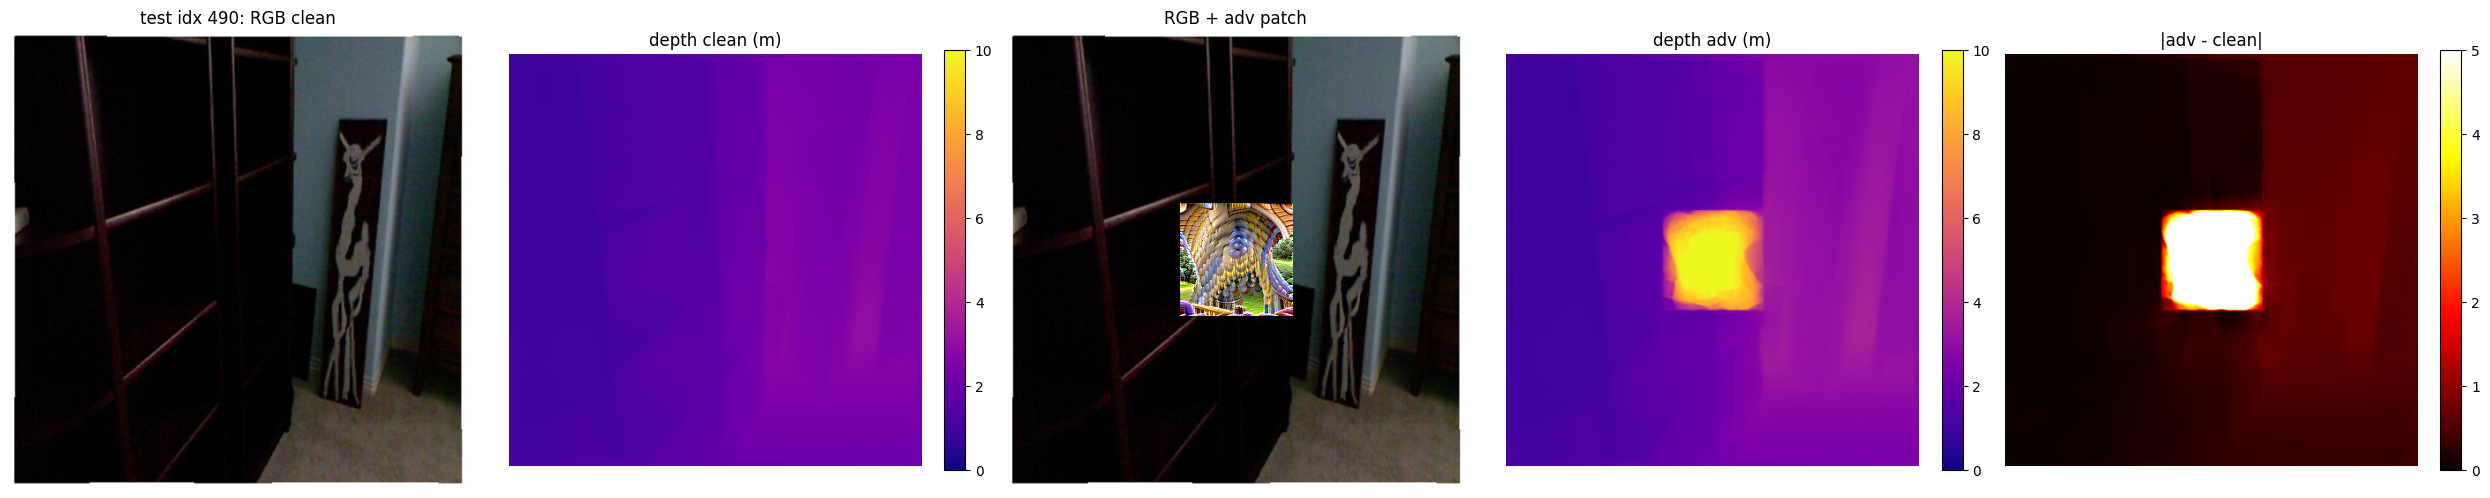

  saved D:\cv\checkpoints\viz_task2\attack_00_idx0490.png


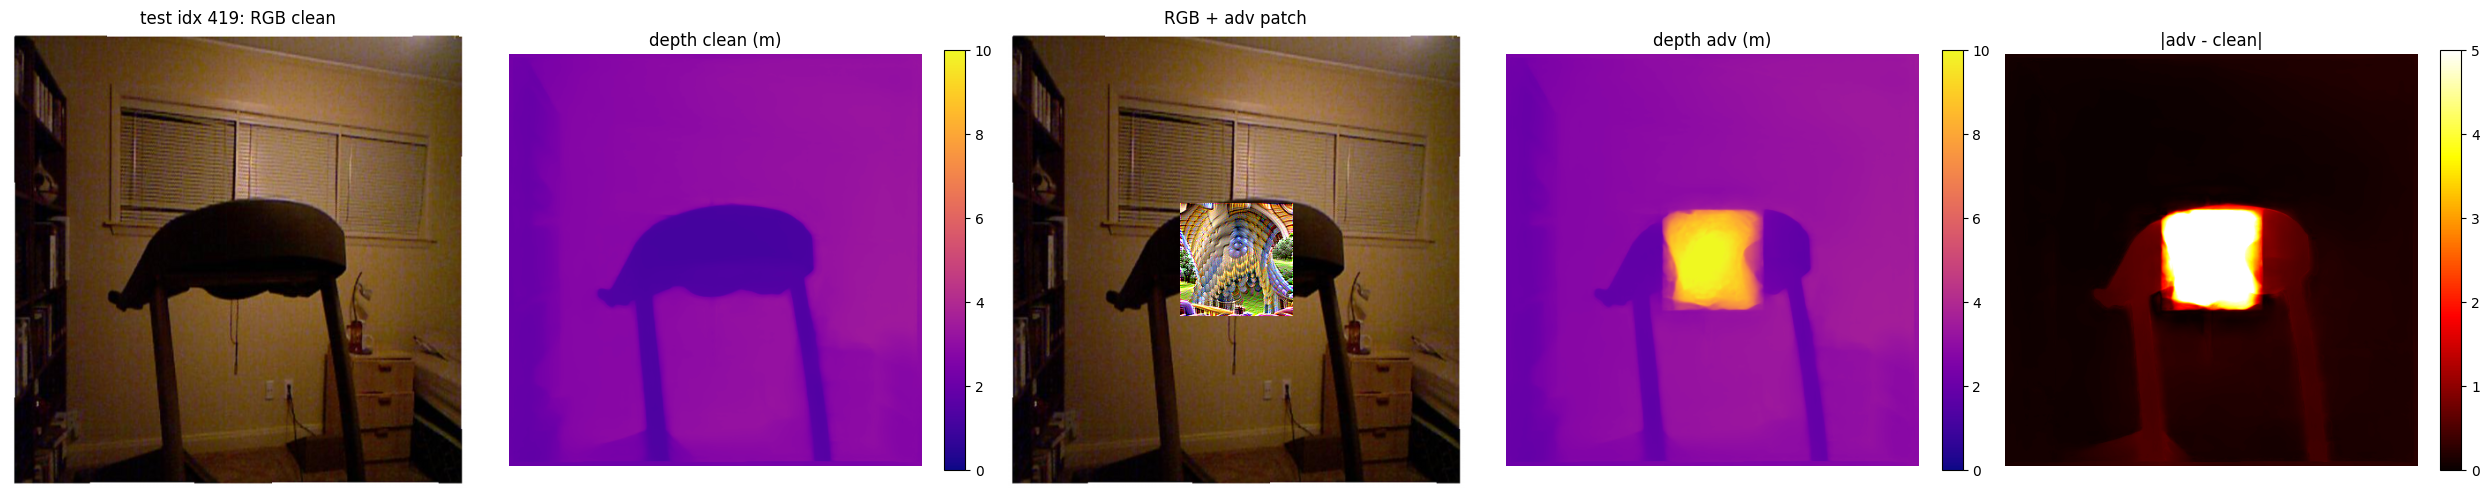

  saved D:\cv\checkpoints\viz_task2\attack_01_idx0419.png


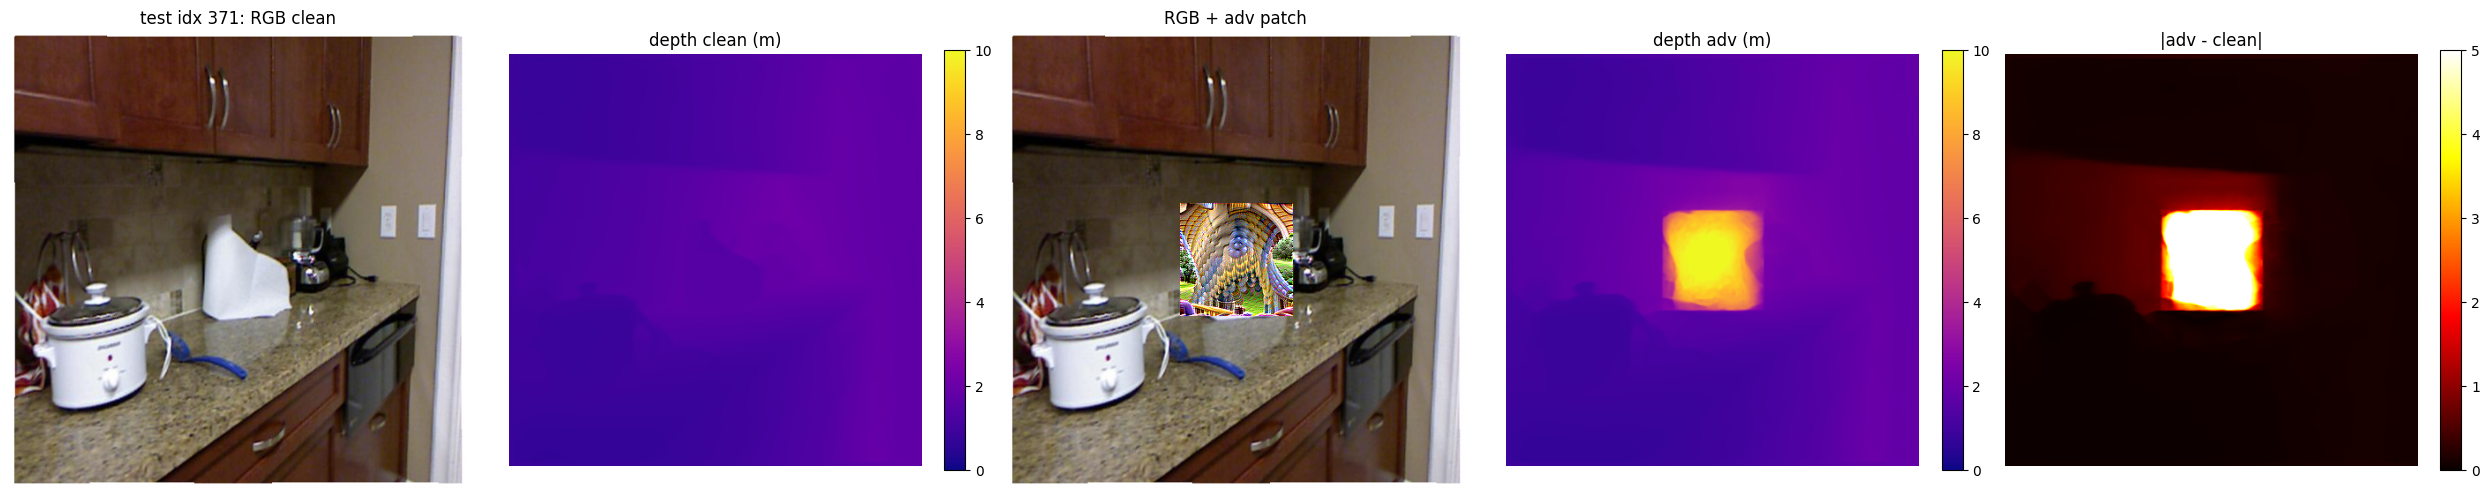

  saved D:\cv\checkpoints\viz_task2\attack_02_idx0371.png


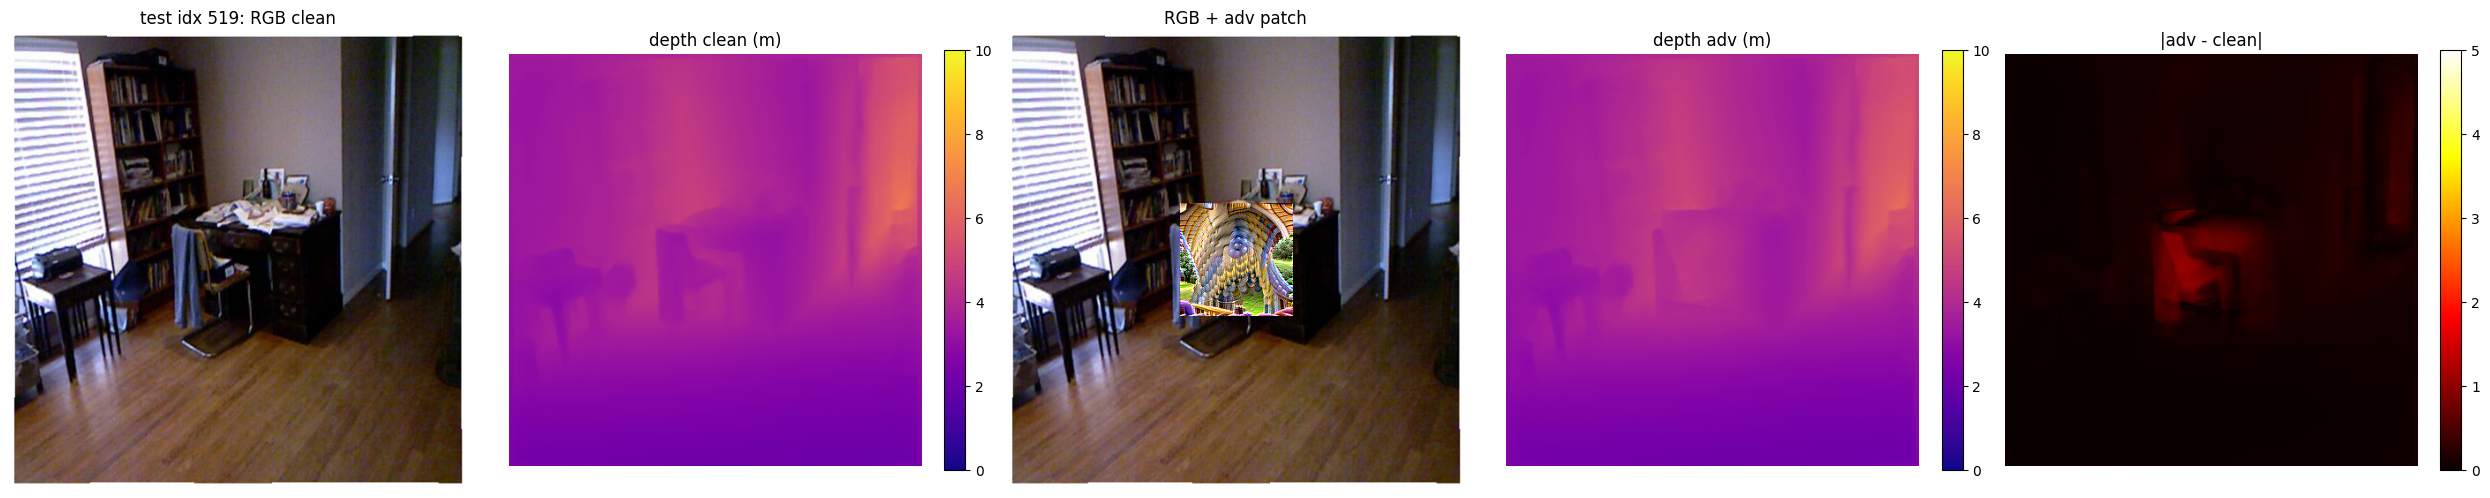

  saved D:\cv\checkpoints\viz_task2\attack_03_idx0519.png


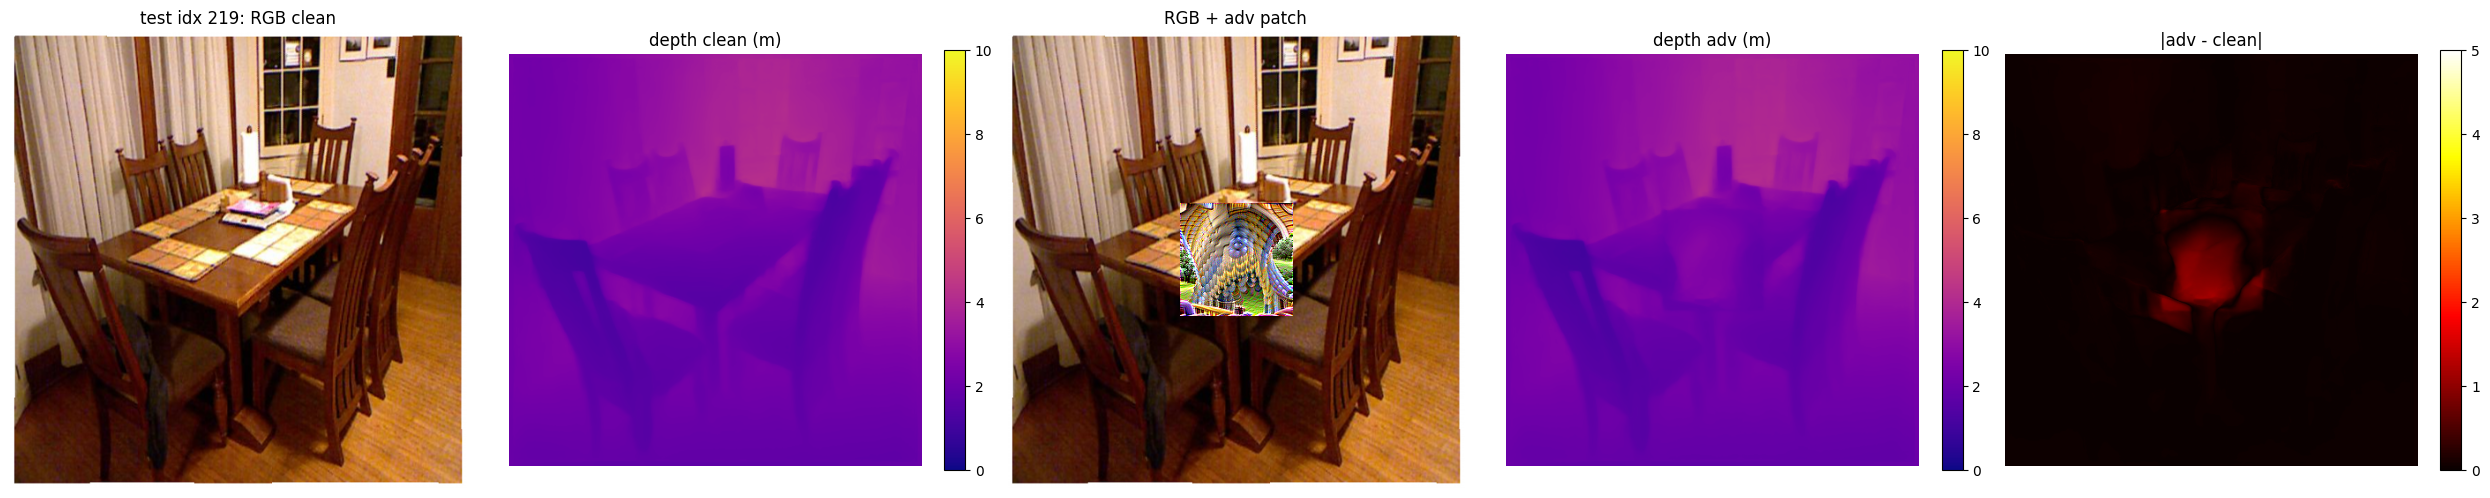

  saved D:\cv\checkpoints\viz_task2\attack_04_idx0219.png


In [ ]:
def viz_panel(idx, save_path):
    _, rgb, comp, pred_clean, pred_adv, mask = depth_shift_for_index(idx)
    rgb_np = rgb.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    comp_np = comp.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    pc = pred_clean.squeeze(0).detach().cpu().numpy()
    pa = pred_adv.squeeze(0).detach().cpu().numpy()
    diff = np.abs(pa - pc)
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    axes[0].imshow(rgb_np); axes[0].set_title(f'test idx {idx}: RGB clean'); axes[0].axis('off')
    im1 = axes[1].imshow(pc, cmap='plasma', vmin=0, vmax=MAX_DEPTH)
    axes[1].set_title('depth clean (m)'); axes[1].axis('off'); plt.colorbar(im1, ax=axes[1], fraction=0.046)
    axes[2].imshow(comp_np); axes[2].set_title('RGB + adv patch'); axes[2].axis('off')
    im3 = axes[3].imshow(pa, cmap='plasma', vmin=0, vmax=MAX_DEPTH)
    axes[3].set_title('depth adv (m)'); axes[3].axis('off'); plt.colorbar(im3, ax=axes[3], fraction=0.046)
    im4 = axes[4].imshow(diff, cmap='hot', vmin=0, vmax=5.0)
    axes[4].set_title('|adv - clean|'); axes[4].axis('off'); plt.colorbar(im4, ax=axes[4], fraction=0.046)
    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()
for _rank, _idx in enumerate(_picks):
    _p = os.path.join(VIZ_DIR, f'attack_{_rank:02d}_idx{_idx:04d}.png')
    viz_panel(_idx, _p)
    print(f'  saved {_p}')


In [ ]:
from PIL import Image as _PILImage
_panel_paths = sorted([os.path.join(VIZ_DIR, f) for f in os.listdir(VIZ_DIR) if f.startswith('attack_')])
_imgs = [_PILImage.open(p) for p in _panel_paths[:5]]
if _imgs:
    _w = max(im.width for im in _imgs)
    _h = sum(im.height for im in _imgs)
    _collage = _PILImage.new('RGB', (_w, _h), (255, 255, 255))
    _y = 0
    for _im in _imgs:
        _collage.paste(_im, (0, _y)); _y += _im.height
    _collage_path = os.path.join(VIZ_DIR, 'attack_collage.png')
    _collage.save(_collage_path)
    print(f'Saved collage: {_collage_path}')


Saved collage: D:\cv\checkpoints\viz_task2\attack_collage.png


### 7e. Attack report JSON

In [ ]:
def _sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        while True:
            chunk = f.read(65536)
            if not chunk: break
            h.update(chunk)
    return h.hexdigest()
attack_report = {
    'task': 'task2_invisibility_cloak_depth_deception',
    'objective': 'push_farther_erase',
    'target_depth_m': TARGET_DEPTH,
    'patch': {
        'size': [3, PATCH_SIZE, PATCH_SIZE],
        'sha256_pt': _sha256(PATCH_PATH),
        'path': PATCH_PATH,
    },
    'hyperparams': {
        'patch_size': PATCH_SIZE, 'input_size': INPUT_SIZE,
        'n_steps': N_STEPS, 'attack_batch': ATTACK_BATCH, 'attack_lr': ATTACK_LR,
        'lambda_adv': LAMBDA_ADV, 'lambda_nps': LAMBDA_NPS, 'lambda_tv': LAMBDA_TV,
        'eot': {
            'rot_deg': EOT_ROT_DEG,
            'scale': [EOT_SCALE_MIN, EOT_SCALE_MAX],
            'trans_frac': EOT_TRANS_FRAC,
            'brightness': EOT_BRIGHT,
            'contrast': [EOT_CONTRAST_MIN, EOT_CONTRAST_MAX],
            'noise_std': EOT_NOISE_STD,
        },
        'mask_dilate_px': MASK_DILATE_PX,
        'seed': SEED,
        'adv_loss': 'log_barrier',
        'adv_loss_eps': ADV_LOSS_EPS,
        'grad_clip_patch': GRAD_CLIP_PATCH,
        'patch_version': 'v2_logbarrier_128',
    },
    'printable_palette_size': PRINTABLE_COLORS.shape[0],
    'clean_metrics_reproduced': _clean_metrics,
    'baseline_metrics_reference': _baseline,
    'adv_deterministic': {
        'metrics': adv_det_metrics,
        'patch_region': adv_det_patch_stats,
    },
    'adv_random_eot_3seeds': {
        'metrics': adv_rnd_metrics,
        'patch_region': adv_rnd_patch_stats,
    },
    'model_checkpoint_path': BEST_MODEL_PATH,
    'timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),
}
with open(REPORT_PATH, 'w') as f:
    json.dump(attack_report, f, indent=2)
print(f'Saved: {REPORT_PATH}')
print(f'\nHeadline:')
print(f'  baseline delta1={_baseline["delta1"]:.4f} -> adv_det delta1={adv_det_metrics["delta1"]:.4f}')
print(f'  attack_success_rate (det)   = {adv_det_patch_stats["frac_pred_gt_8m"]:.4f}')
print(f'  attack_success_rate (rnd)   = {adv_rnd_patch_stats["frac_pred_gt_8m"]:.4f}')
print(f'  mean_pred_in_mask (det)     = {adv_det_patch_stats["mean_pred_in_mask"]:.3f} m')


Saved: D:\cv\checkpoints\attack_report.json

Headline:
  baseline delta1=0.9351 -> adv_det delta1=0.8327
  attack_success_rate (det)   = 0.4930
  attack_success_rate (rnd)   = 0.5000
  mean_pred_in_mask (det)     = 7.319 m
